# Compare Selected Tree and Linear Regression Models

The purpose of this notebook is to compare the best identified tree based and linear regression model. Its focus is especially important because the tree based model was not evaluated on a curated, reduced dataset the way that the best ridge model was, where actually it was found that in 2025 a simple linear regression with no regularisation does best. Also, on this dataset the linear regression model performed better than the ETR on its respective best configuration.

In [ ]:
import json
from itertools import product
from pathlib import Path


import numpy as np
import pandas as pd
import geopandas as gpd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from shapely.geometry import shape

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score

import shap

from scipy.stats import spearmanr

import warnings
warnings.filterwarnings("ignore")





from sklearn.ensemble import ExtraTreesRegressor
from sklearn.pipeline import Pipeline

RANDOM_STATE = 19

## Data Cleaning and Preparation

Note script here is repeated from previous notebooks with cleaning and preparation steps being identical

### Perform Loads and Joins

In [ ]:
base_path = Path('.')  # current notebook directory

snapshots = ["2025"]
snapshot_dfs = {}

for snapshot in snapshots:
    dfs = []
    snapshot_path = base_path / snapshot
    
    for folder in snapshot_path.iterdir():
        if folder.is_dir():
            for file in folder.glob("*.parquet"):
                df = pd.read_parquet(file)
                dfs.append(df)
    
    snapshot_dfs[snapshot] = pd.concat(dfs, ignore_index=True)
    print(f"{snapshot} shape:", snapshot_dfs[snapshot].shape)

features_2025 = snapshot_dfs["2025"]

2025 shape: (1273, 434)


In [163]:
scores_2025 = pd.read_csv('imd_2025_scores.csv')

lsoa_lookup = pd.read_csv('lsoa_lookup.csv')

In [164]:



scores_2025.rename(columns={'LSOA code (2021)': 'lsoa_code',
                           'Index of Multiple Deprivation (IMD) Score': 'imd_score'
                          }, inplace=True)

scores_2025 = scores_2025[['lsoa_code', 'imd_score']]

# Merge features and target datasets on 'lsoa_code'
data_2025 = pd.merge(features_2025, scores_2025, on='lsoa_code', how='inner')

### Clean Data 

In [165]:
print(data_2025.shape)

(1273, 435)


#### Deal with Null, NaN and Inf

First infinite values are replaced with NaN

In [166]:
if np.isinf(data_2025.select_dtypes(include=['number'])).sum().sum()>0:
    print("Warning: Infinite values found in 2025 dataset.")
    data_2025.replace([np.inf, -np.inf], np.nan, inplace=True)

Check missingness and drop features with >20% missing values, then impute remaining missing values with median

In [167]:
# 2025
missingness = data_2025.isna().sum().sort_values(ascending=False)
missingness_percent = (missingness / len(data_2025)) * 100
missingness_2025_df = pd.DataFrame({
    'feature': missingness.index,
    'missing_count': missingness.values,
    'missing_percent': missingness_percent.values
})

data_2025 = data_2025.drop(columns=missingness_2025_df[missingness_2025_df['missing_percent'] > 20]['feature'])
data_2025 = data_2025.fillna(data_2025.median(numeric_only=True)) 

missingness_2025_df.sort_values('missing_percent', ascending=False).head(10)

,feature,missing_count,missing_percent
0,landuse_aquaculture_0,1195,93.872742
1,landuse_paddock_0,1195,93.872742
2,landuse_private_0,1109,87.117046
3,landuse_basin_0,1093,85.860173
4,landuse_churchyard_0,1093,85.860173
5,landuse_highway_0,1031,80.989788
6,landuse_storage_0,1005,78.947368
7,landuse_terminal_0,1005,78.947368
8,landuse_proposed_construction_0,930,73.055774
9,landuse_proposed_station_0,930,73.055774


### Filter Data to Curated Features

In [168]:
# function below is taken from "interpolation_modelling" notebook, it creates the curated dataset for comparison across models
data_2025["lsoa_population"] = data_2025["aged_under_15"] + data_2025["working_age_population"] + data_2025["pension_age_population"]

def create_rate_features(raw: pl.DataFrame)-> pl.DataFrame:
    return raw.with_columns(
        (pl.col("total_crimes") / pl.col("lsoa_population") * 1000).alias("crime_rate_per_1000"),
        (pl.col("violent-crime") / pl.col("lsoa_population") * 1000).
        alias("violent_crime_rate"),
        (pl.col("burglary") / pl.col("lsoa_population") * 1000).
        alias("burglary_rate"),
        (pl.col("drugs") / pl.col("lsoa_population") * 1000).
        alias("drugs_rate"),
        (pl.col("total_claims") / pl.col("working_age_population")).
        alias("uc_claim_rate"),
        (pl.col("total_nwr_claims") / pl.col("working_age_population")).
        alias("uc_nwr_rate"),
        (pl.col("total_transactions") / pl.col("lsoa_population") * 1000).
        alias("transactions_per_capita"),
        (pl.col("aged_under_15") / pl.col("lsoa_population")).
        alias("youth_share"),
        (pl.col("pension_age_population") / pl.col("lsoa_population")).
        alias("elderly_share"))

data = create_rate_features(pl.from_pandas(data_2025)).select([
    "crime_rate_per_1000",
    "violent_crime_rate",
    "burglary_rate",
    "drugs_rate",
    "resolution_rate",
    "uc_claim_rate",
    "uc_nwr_rate",
    "%_claims_planfw",
    "%_claims_sfw",
    "lsoa_mean_price",
    "lsoa_median_price",
    "lsoa_price_inequality",
    "transactions_per_capita",
    "flats_proportion",
    "terraced_proportion",
    "detached_proportion",
    "freehold_proportion",
    "landuse_residential_0",
    "landuse_industrial_0",
    "landuse_commercial_0",
    "streetlit_percentage",
    "youth_share",
    "elderly_share",
    "imd_score",
    "lsoa_code"]).to_pandas()

### Load and Prepare Geospatial Data

#### Load Geo Shapes

In [ ]:
lsoa_shapes = gpd.read_file("lsoa_boundaries.gpkg")

# convert geojson string to geometry
lsoa_shapes = lsoa_shapes[['lsoa_code', 'geometry']]

print(lsoa_shapes.head())

# merge modelling data to get full geo-spatial dataset
gdf = gpd.GeoDataFrame(lsoa_shapes, geometry='geometry', crs='EPSG:4326').merge(data, on='lsoa_code', how='inner')


   lsoa_code                                           geometry
0  E01007823  MULTIPOLYGON (((434645.001 381807.48, 434647 3...
1  E01007824  MULTIPOLYGON (((434345.346 381754.22, 434232 3...
2  E01007825  MULTIPOLYGON (((433651.451 383037.564, 433518....
3  E01007826  MULTIPOLYGON (((432954.351 381546.363, 432488....
4  E01007827  MULTIPOLYGON (((436586.188 383704.594, 436623....


#### Get Spatial CV Clusters

In [170]:
# Setup for spatial cross validation 

centroids = np.array(list(zip(gdf.geometry.centroid.x, gdf.geometry.centroid.y)))
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE).fit(centroids)
gdf['cluster_id'] = kmeans.labels_

groups = gdf['cluster_id'].values

### Assign Features and Target

In [171]:
data = data.sort_values(by='lsoa_code').set_index('lsoa_code')
X = data.drop(columns=['imd_score'])
y = data['imd_score']

## Perform Spatial CV

In [ ]:
etr_params = {
    'model__max_depth': 5,
    'model__max_features': 0.5,
    'model__min_samples_leaf': 5,
    'model__min_samples_split': 20,
    'model__n_estimators': 500
}

gkf = GroupKFold(n_splits=8)

In [ ]:

results_row = []

for model in ['ExtraTreesRegressor', 'LinearRegression']:
    fold = 1
    for train_idx, test_idx in gkf.split(X, y, groups=groups):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        if model == 'ExtraTreesRegressor':
            pipe = Pipeline([
                ('StandardScaler', StandardScaler()),
                ('model', ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1))
            ])
        else:
            pipe = Pipeline([
                ('StandardScaler', StandardScaler()),
                ('model', LinearRegression())
            ])
        if model == 'ExtraTreesRegressor':
            pipe.set_params(**etr_params)
        
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        results_row.append({
            'model': model,
            'fold' : fold,
            'r2_scores': r2_score(y_test, y_pred),
            'rmse_scores': np.sqrt(mean_squared_error(y_test, y_pred)),
            'spearmensr_scores': spearmanr(y_test, y_pred)[0],
            'coeffs': pipe['model'].coef_ if model == 'LinearRegression' else pipe['model'].feature_importances_
        })
        fold += 1

results_df = pd.DataFrame(results_row)


In [174]:
results_df

,model,fold,r2_scores,rmse_scores,spearmensr_scores,coeffs
0,ExtraTreesRegressor,1,0.923462,3.278827,0.966332,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.32993083336031065,..."
1,ExtraTreesRegressor,2,0.913186,6.174130,0.971717,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.3311933603994534, ..."
2,ExtraTreesRegressor,3,0.872837,5.013925,0.973778,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.31987542575072947,..."
3,ExtraTreesRegressor,4,0.917268,4.555380,0.950657,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.3367663908789414, ..."
4,ExtraTreesRegressor,5,0.899434,5.586546,0.947187,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.3324053311940707, ..."
5,ExtraTreesRegressor,6,0.913660,4.639973,0.959721,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.33191915328382166,..."
6,ExtraTreesRegressor,7,0.949713,4.351615,0.977076,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.41261746179274417,..."
7,ExtraTreesRegressor,8,0.933627,4.700596,0.967686,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.3358086002639636, ..."
8,LinearRegression,1,0.927225,3.197209,0.965690,"[0.0, 1.3322676295501878e-15, 6.21724893790087..."
9,LinearRegression,2,0.966263,3.848882,0.983133,"[0.0, 2.731148640577885e-14, 1.421085471520200..."


## Evaluate Performance Metrics

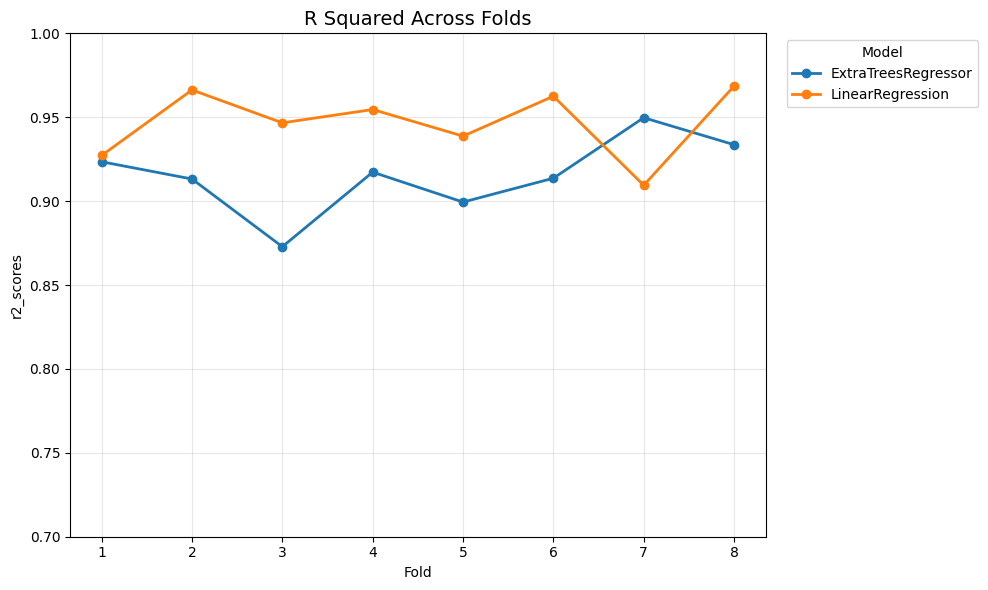

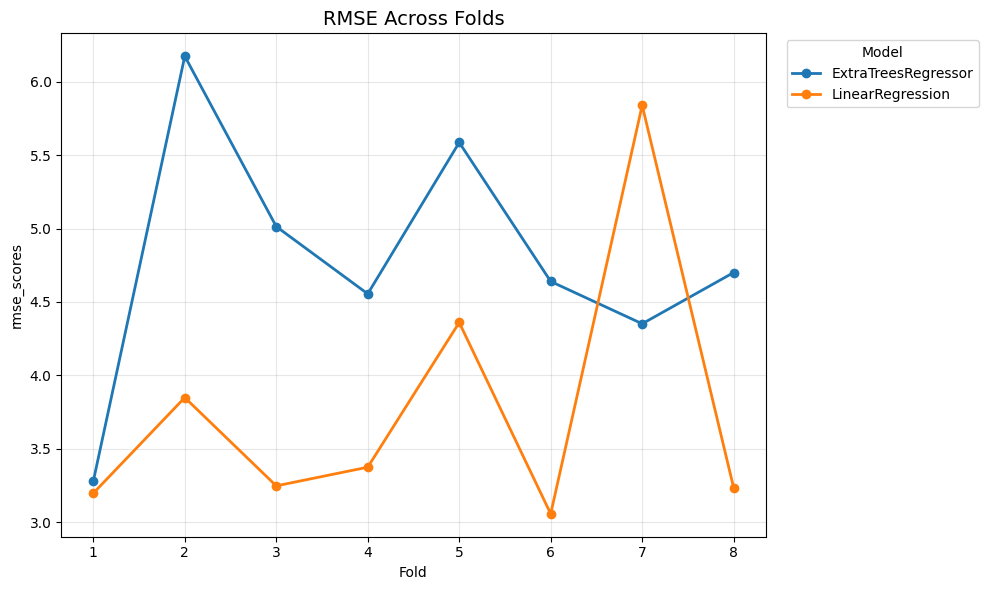

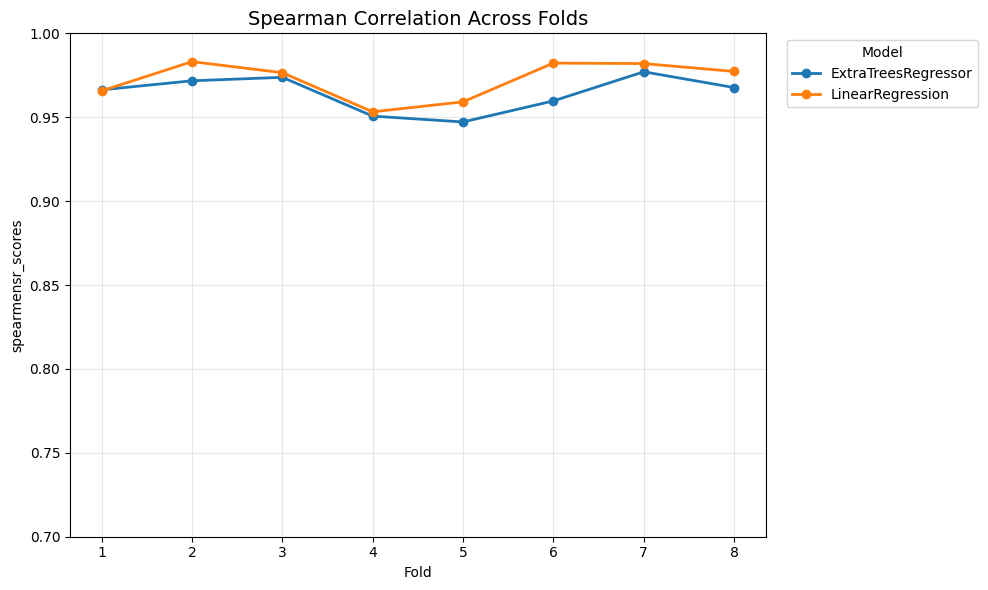

In [175]:
metrics = {
    "r2_scores": "R Squared Across Folds",
    "rmse_scores": "RMSE Across Folds",
    "spearmensr_scores": "Spearman Correlation Across Folds"
}

for metric_col, title in metrics.items():

    plt.figure(figsize=(10, 6))

    for model_name, grp in results_df.groupby("model"):
        grp = grp.sort_values("fold")

        plt.plot(
            grp["fold"],
            grp[metric_col],
            marker="o",
            linewidth=2,
            label=model_name
        )

    if metric_col != "rmse_scores":
        plt.ylim(0.7, 1)

    plt.title(title, fontsize=14)
    plt.xlabel("Fold")
    plt.ylabel(metric_col)
    plt.xticks(sorted(results_df["fold"].unique()))
    plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Initial plots of performance metrics show simple linear regression outperforming the ETR model. It is interesting to see the simpler model perform just as well if not better than the more complex one.

On model stability, metric spread is observed:

In [176]:
results_df.groupby("model")[["r2_scores", "rmse_scores", "spearmensr_scores"]].std()


,r2_scores,rmse_scores,spearmensr_scores
model,,,
ExtraTreesRegressor,0.022843,0.858717,0.010847
LinearRegression,0.020719,0.940440,0.011546


Here differences in spread are seen to be not significant.

In [ ]:
feature_names = data.columns 

rows = []

for _, row in results_df.iterrows():

    coeff_array = np.array(row["coeffs"]).flatten()

    for feature, coef in zip(feature_names, coeff_array):

        rows.append({
            "model": row["model"],
            "fold": row["fold"],
            "feature": feature,
            "coef": coef
        })

coef_df = pd.DataFrame(rows)

In [178]:
coef_df

,model,fold,feature,coef
0,ExtraTreesRegressor,1,crime_rate_per_1000,0.000000
1,ExtraTreesRegressor,1,violent_crime_rate,0.000000
2,ExtraTreesRegressor,1,burglary_rate,0.000000
3,ExtraTreesRegressor,1,drugs_rate,0.000000
4,ExtraTreesRegressor,1,resolution_rate,0.000000
...,...,...,...,...
363,LinearRegression,8,landuse_industrial_0,-0.419190
364,LinearRegression,8,landuse_commercial_0,0.006315
365,LinearRegression,8,streetlit_percentage,-0.017040
366,LinearRegression,8,youth_share,-0.744658


In [179]:
summary = coef_df.groupby(["model", "feature"]).agg(
    mean_coef=("coef", "mean"),
    std_coef=("coef", "std")
).reset_index()

In [180]:
summary

,model,feature,mean_coef,std_coef
0,ExtraTreesRegressor,%_claims_planfw,6.313947e-02,1.276315e-02
1,ExtraTreesRegressor,%_claims_sfw,5.008223e-03,1.125433e-03
2,ExtraTreesRegressor,burglary_rate,0.000000e+00,0.000000e+00
3,ExtraTreesRegressor,crime_rate_per_1000,0.000000e+00,0.000000e+00
4,ExtraTreesRegressor,detached_proportion,3.580896e-02,7.833853e-03
5,ExtraTreesRegressor,drugs_rate,0.000000e+00,0.000000e+00
6,ExtraTreesRegressor,elderly_share,2.285511e-02,2.340720e-03
7,ExtraTreesRegressor,flats_proportion,1.046821e-03,1.917426e-04
8,ExtraTreesRegressor,freehold_proportion,7.671410e-04,9.259468e-05
9,ExtraTreesRegressor,landuse_commercial_0,4.902528e-04,1.560008e-04


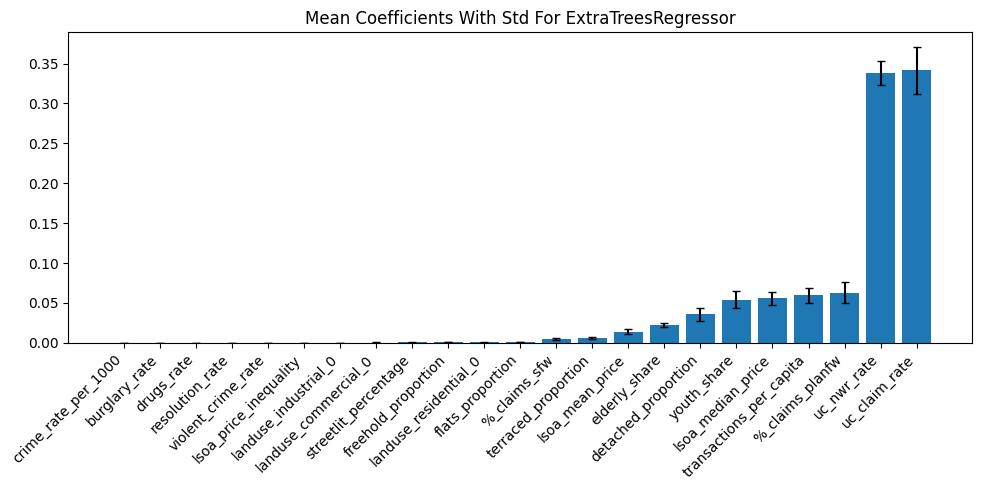

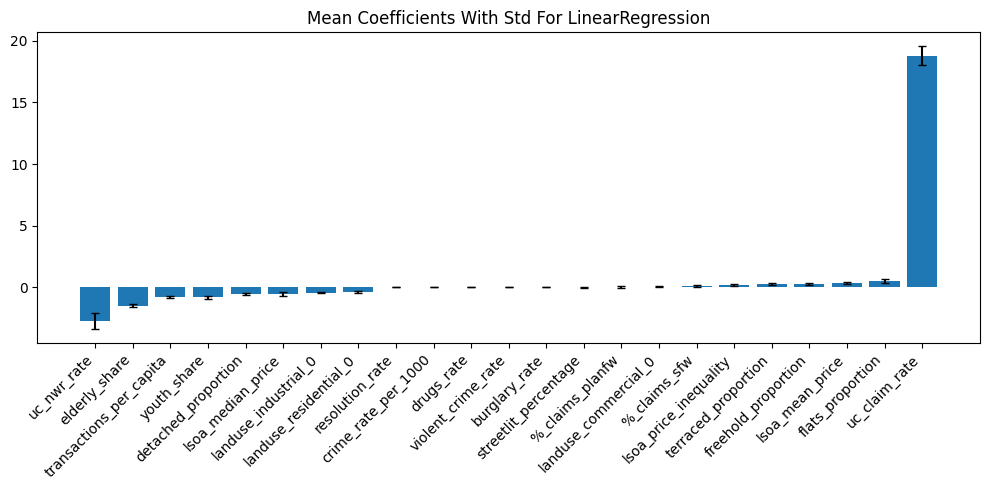

In [197]:
for model_name, df_m in summary.groupby("model"):

    df_m = df_m.sort_values("mean_coef")

    plt.figure(figsize=(10, 5))

    plt.bar(
        df_m["feature"],
        df_m["mean_coef"],
        yerr=df_m["std_coef"],
        capsize=3
    )

    plt.title(f"Mean Coefficients With Std For {model_name}")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

As before, UC is found to be the strongest signal, with relatively low spread indicating this to be stable on the linear regressor. On the ETR, uc_nwr is also kept as almost equally important to the uc_claim_rate, unlike the linear model which just uses one UC feature. Also, the ETR seems to give a bit more weight to the other features. For more direct comparison however, a scaled plot of features side by side is produced.

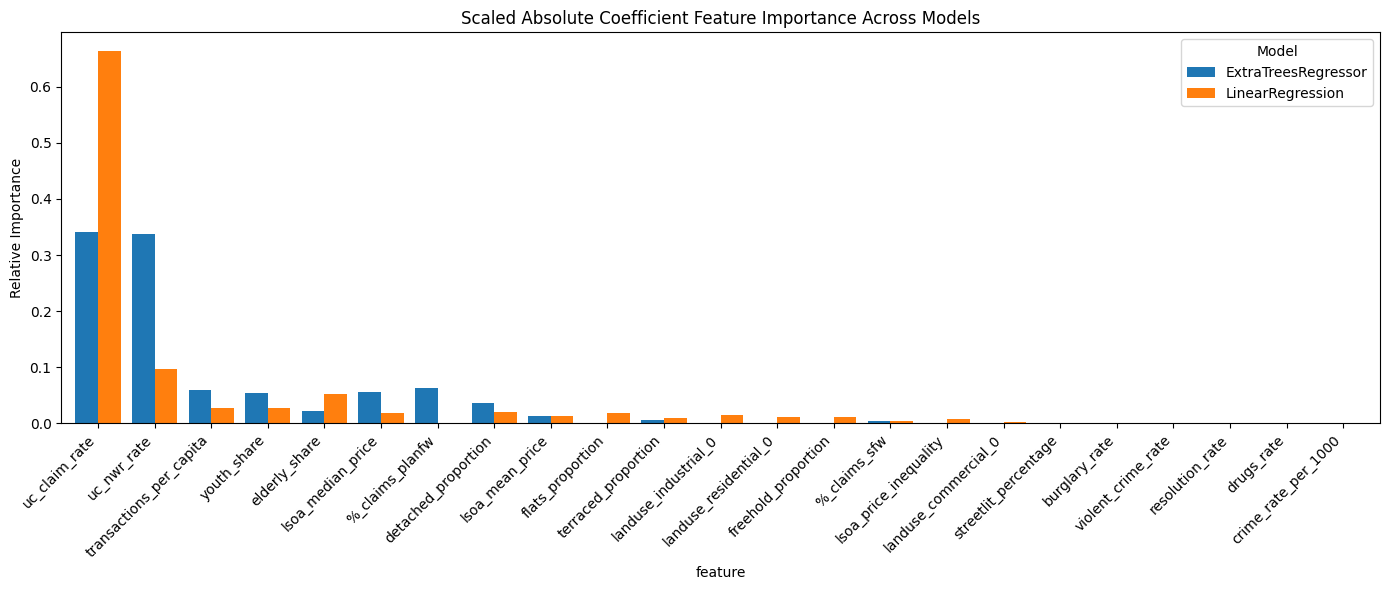

In [ ]:

importance_rows = []

for model_name, df_m in summary.groupby("model"):
    
    temp = df_m.copy()
    temp["abs_coef"] = temp["mean_coef"].abs()
    
    # scale within each model
    total = temp["abs_coef"].sum()
    temp["scaled_importance"] = temp["abs_coef"] / total if total != 0 else 0
    
    temp["model"] = model_name
    
    importance_rows.append(
        temp[["model", "feature", "scaled_importance"]]
    )

plot_df = pd.concat(importance_rows).pivot(
    index="feature",
    columns="model",
    values="scaled_importance"
).fillna(0)

# sort bars
plot_df["avg"] = plot_df.mean(axis=1)
plot_df = plot_df.sort_values("avg", ascending=False).drop(columns="avg")

plot_df.plot(
    kind="bar",
    figsize=(14,6),
    width=0.8
)

plt.title("Scaled Absolute Coefficient Feature Importance Across Models")
plt.ylabel("Relative Importance")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

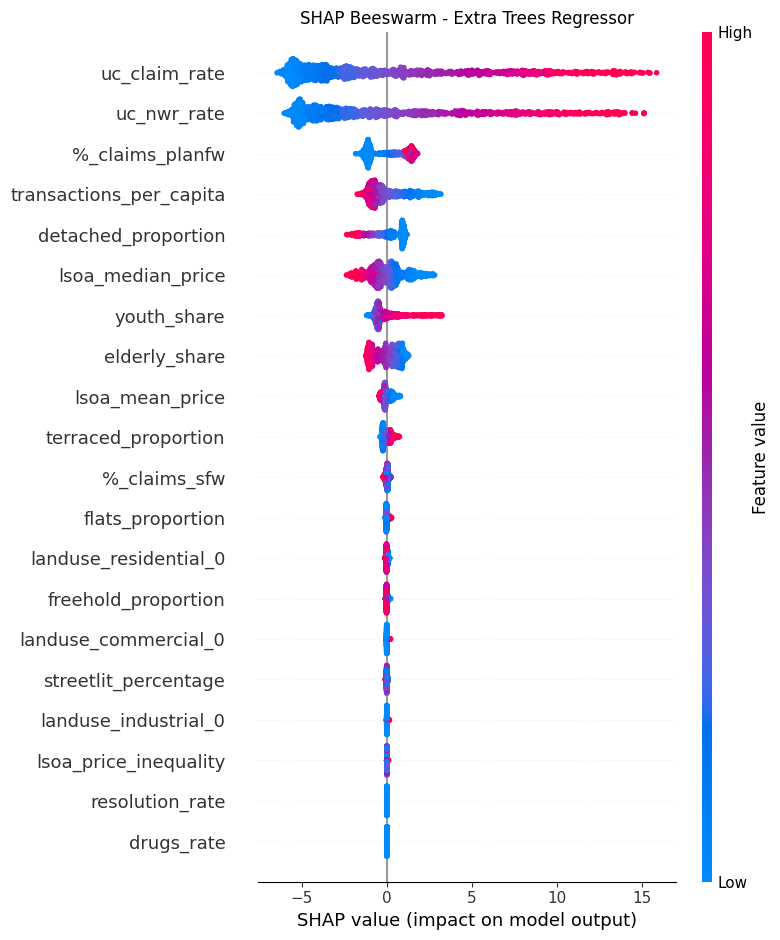

In [183]:


pipe = Pipeline([
    ('model', ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1))
])
pipe.set_params(**etr_params)
pipe.fit(X, y)

explainer = shap.TreeExplainer(pipe.named_steps["model"])
shap_values = explainer.shap_values(X)

plt.figure(figsize=(10,6))
shap.summary_plot(
    shap_values,
    X,
    plot_type="dot",
    show=False
)

plt.title("SHAP Beeswarm - Extra Trees Regressor")
plt.tight_layout()
plt.show()